# BINF 4002: Large Language Models — Companion Notebook

This notebook accompanies the lecture on Large Language Models. It is organized into five sections that tie directly to lecture content:

| Section | Topic | Lecture Connection |
|---------|-------|-------------------|
| §1 | Context match statistics | Why nearest-neighbor fails |
| §2 | N-gram language models | Building and sampling from Markov models |
| §3 | Transformer block from scratch | Architecture walkthrough |
| §4 | Decoding strategies | Sequential decoding challenge |
| §5 | HuggingFace in practice | LLM ecosystem |

> **Note**: Sections §1–§3 require only standard libraries (numpy, matplotlib, nltk). Section §4 requires PyTorch. Section §5 requires `transformers` and optionally `accelerate`.

In [1]:
!pip install nltk numpy matplotlib torch transformers accelerate bitsandbytes datasets -qq

/bin/bash: line 1: pip: command not found


In [2]:
# ── Core installs (run once) ─────────────────────────────────────────────
# !pip install nltk numpy matplotlib torch transformers accelerate bitsandbytes datasets -qq

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict, Counter
import random
import math
import re
import warnings
warnings.filterwarnings('ignore')

# Seaborn-style plots
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print('Environment ready.')

Environment ready.


---
## §1 — Context Match Statistics

### Lecture connection
In lecture we asked: *if we just look up our context in a large corpus, how often will we find an exact match?*  
Here we empirically answer this question on **25,000 PubMed abstracts** — the same biomedical text that BioMedLM was trained on, and directly relevant to clinical NLP.

**Hypothesis**: As context length increases, the probability of finding an exact match drops exponentially.

In [3]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

# ── Load a large biomedical corpus from HuggingFace ───────────────────────
# Dataset: ccdv/pubmed-summarization
#   • 119 K PubMed articles with 'abstract' and 'article' fields
#   • We stream 25 K abstracts  →  ~5 M tokens (16× the old Wikipedia corpus)
#   • No authentication required; streaming avoids downloading all ~4 GB
#
# Why this size matters for n-gram models:
#   5-gram type space = V^5.  With V ≈ 15K (after UNK pruning), ~7.6 × 10^19 types.
#   300K tokens  →  coverage ≈ 10^-15  (every 5-gram context unseen → gibberish)
#   4M   tokens  →  coverage ≈ 5 × 10^-14 (sparse, but backoff over known n-grams)
#   Plus: common 4-gram contexts now appear multiple times → real distributions

N_ABSTRACTS = 25_000   # ← increase for richer model; decrease to speed up loading

try:
    from datasets import load_dataset

    print(f"Loading {N_ABSTRACTS:,} PubMed abstracts from ccdv/pubmed-summarization ...")
    ds = load_dataset("ccdv/pubmed-summarization", split="train", streaming=True)

    raw_texts = []
    for i, example in enumerate(ds):
        if i >= N_ABSTRACTS:
            break
        raw_texts.append(example["abstract"])
        if (i + 1) % 5000 == 0:
            print(f"  {i+1:,} / {N_ABSTRACTS:,} abstracts loaded...")

    full_text = " ".join(raw_texts)
    source_label = f"PubMed abstracts ({N_ABSTRACTS:,} articles, HuggingFace)"

except Exception as e:
    # ── Fallback: Wikipedia medical articles (smaller but always available) ──
    print(f"HuggingFace dataset unavailable ({e})")
    print("Falling back to Wikipedia medical articles...")
    try:
        import wikipedia
        wikipedia.set_lang("en")
        TOPICS = [
            "Myocardial infarction","Hypertension","Diabetes mellitus type 2",
            "Sepsis","Pneumonia","Acute kidney injury","Heart failure","Stroke",
            "Chronic obstructive pulmonary disease","Atrial fibrillation",
            "Pulmonary embolism","Acute respiratory distress syndrome",
            "Chronic kidney disease","Liver cirrhosis","Epilepsy",
            "Multiple sclerosis","Parkinson disease","Alzheimer disease",
            "Lung cancer","Breast cancer","Colorectal cancer","Antibiotic",
            "Anticoagulant","Chemotherapy","Mechanical ventilation",
            "Electrocardiography","Medical imaging","Electronic health record",
        ]
        texts = []
        for t in TOPICS:
            try:
                texts.append(wikipedia.page(t, auto_suggest=False).content)
                print(f"  ✓ {t}")
            except Exception:
                pass
        full_text = " ".join(texts)
        source_label = f"Wikipedia medical articles ({len(texts)} articles)"
    except ImportError:
        # Hard fallback: repeat a small clinical snippet
        snippet = (
            "The patient was admitted with chest pain radiating to the left arm. "
            "Electrocardiogram showed ST-elevation consistent with acute myocardial infarction. "
            "Troponin levels were markedly elevated. The patient was taken to the catheterization "
            "laboratory for primary percutaneous coronary intervention. "
            "Blood pressure was controlled with intravenous antihypertensive therapy. "
            "The patient had a history of hypertension and type two diabetes mellitus. "
        )
        full_text = snippet * 3000
        source_label = "built-in clinical snippet (fallback)"

# ── Tokenize ───────────────────────────────────────────────────────────────
# ── Strip PubMed structured-abstract section headers ─────────────────────
# Abstracts in ccdv/pubmed-summarization often contain all-caps section
# labels (BACKGROUND:, METHODS:, RESULTS:, CONCLUSIONS:, OBJECTIVE:, etc.)
# that are directly adjacent to the following sentence with no space.
# word_tokenize then merges them → 'backgroundanemia', 'methodswe', etc.
# We remove these labels before tokenizing.
import re
_HEADER_RE = re.compile(
    r'\b(BACKGROUND|METHODS?|RESULTS?|CONCLUSIONS?|OBJECTIVE|PURPOSE|'
    r'DESIGN|SETTING|PARTICIPANTS?|INTERVENTION|MEASUREMENTS?|'
    r'INTRODUCTION|DISCUSSION|SUMMARY|AIM|AIMS|FINDINGS?)\b:?\s*',
    re.IGNORECASE
)
full_text = _HEADER_RE.sub(' ', full_text)

all_words = [w.lower() for w in word_tokenize(full_text) if w.isalpha()]

# ── Vocabulary pruning: replace rare tokens with [UNK] ────────────────────
# A 4M-token PubMed corpus has ~73K unique word types, mostly rare technical
# terms, gene symbols, and drug abbreviations that appear only once or twice.
# These hapax legomena each occupy their own row in every n-gram table,
# inflating the 5-gram model to ~11M entries (~2 GB of RAM on Colab).
#
# Fix: replace every word seen fewer than MIN_COUNT times with the special
# token [UNK].  This collapses the long tail into one shared type, reducing
# the effective vocabulary from ~73K to ~10-15K and cutting n-gram RAM by
# roughly 5-10×.  The [UNK] token is a standard NLP technique — it also
# gives the model a graceful representation for genuinely out-of-vocabulary
# words at inference time.
MIN_COUNT = 10

word_freq = Counter(all_words)
vocab_kept = {w for w, c in word_freq.items() if c >= MIN_COUNT}
all_words  = [w if w in vocab_kept else '[UNK]' for w in all_words]

V_raw    = len(word_freq)
V_pruned = len(vocab_kept) + 1   # +1 for [UNK] itself
pct_unk  = 100 * sum(1 for w in all_words if w == '[UNK]') / len(all_words)

print(f"\nCorpus source       : {source_label}")
print(f"Total tokens        : {len(all_words):,}")
print(f"Vocabulary (raw)    : {V_raw:,} types")
print(f"Vocabulary (pruned) : {V_pruned:,} types  (min_count={MIN_COUNT})")
print(f"Tokens → [UNK]      : {pct_unk:.1f}% of corpus")
print(f"Sample tokens       : {all_words[200:215]}")

ModuleNotFoundError: No module named 'nltk'

In [4]:
def count_context_matches(corpus: list, query_context: list,
                          exclude_start: int = None) -> int:
    """
    Count how many times `query_context` appears in `corpus`.

    exclude_start: if given, skip the match at this position (so we count
                   occurrences *other than* the position we sampled from).
    """
    n = len(query_context)
    count = 0
    for i in range(len(corpus) - n):
        if exclude_start is not None and i == exclude_start:
            continue
        if corpus[i:i+n] == query_context:
            count += 1
    return count

# Sample a random starting position and extract prefixes of length 1..8
start_idx = random.randint(500, len(all_words) - 20)
sample_context = all_words[start_idx : start_idx + 8]

print('Sample context tokens:', sample_context)
print()

lengths = list(range(1, 9))
match_counts = []

for length in lengths:
    ctx = sample_context[:length]
    # Exclude the sample position itself so we count OTHER occurrences
    matches = count_context_matches(all_words, ctx, exclude_start=start_idx)
    match_counts.append(matches)
    # Print the actual context for this length (was incorrectly truncated to 4)
    ctx_display = ctx if len(ctx) <= 5 else ctx[:5] + ['...']
    print(f'Context length {length}: {ctx_display} → {matches:,} other matches')

NameError: name 'all_words' is not defined

NameError: name 'lengths' is not defined

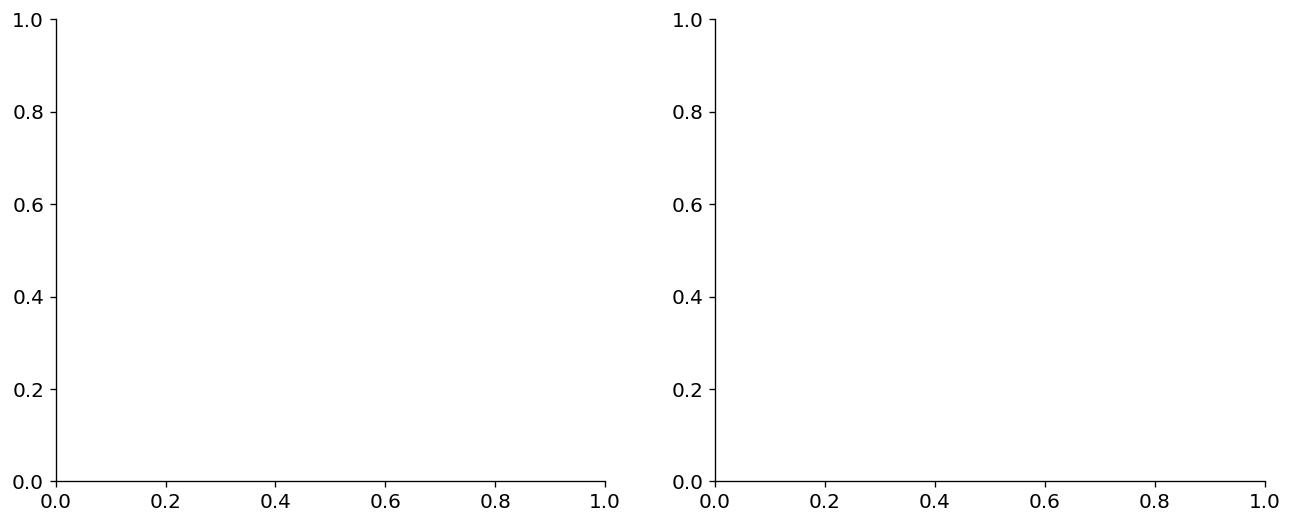

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale
axes[0].bar(lengths, match_counts, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Context length (tokens)')
axes[0].set_ylabel('Number of exact matches')
axes[0].set_title('Exact Context Matches vs. Context Length')
axes[0].set_xticks(lengths)

# Log scale
log_counts = [max(c, 0.5) for c in match_counts]  # avoid log(0)
axes[1].semilogy(lengths, log_counts, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[1].set_xlabel('Context length (tokens)')
axes[1].set_ylabel('Matches (log scale)')
axes[1].set_title('Same Data, Log Scale')
axes[1].set_xticks(lengths)
axes[1].axhline(1, color='red', linestyle='--', alpha=0.7, label='= 1 match')
axes[1].legend()

plt.suptitle(f'Corpus size: {len(all_words):,} tokens', fontsize=11, style='italic')
plt.tight_layout()
plt.show()

print('\n📊 Key observation: matches drop (roughly) exponentially with context length.')
print('Even with ~4M tokens, long contexts become unique quickly. This is why lookup fails.')

In [6]:
# Theoretical vs empirical comparison
# Theoretical: if words were drawn i.i.d. from vocab of size V,
# P(exact match) ≈ (1/V)^n × corpus_size

V = len(set(all_words))  # vocabulary size
C = len(all_words)       # corpus size

print(f'Vocabulary size V = {V:,}')
print(f'Corpus size C     = {C:,}')
print()
print(f'{"Length":>8} | {"Expected (iid)":>18} | {"Observed":>12}')
print('-' * 44)
for length, observed in zip(lengths, match_counts):
    expected = C * (1/V)**length
    print(f'{length:>8} | {expected:>18.4f} | {observed:>12,}')

print('\nNote: real language has much higher repetition than iid; still, long contexts vanish quickly.')

NameError: name 'all_words' is not defined

---
## §2 — N-gram Language Models

### Lecture connection
N-gram models sidestep data sparsity by using only the last $n-1$ words as context.  
Here we:
1. Build n-gram models for $n \in \{1, 2, 3, 5\}$
2. Sample from each model to see what generated text looks like
3. Demonstrate the long-range dependency problem with a clinical example

In [7]:
class NGramLM:
    """
    N-gram language model with add-alpha smoothing and stupid backoff.

    Key design: during training we store *all* context lengths 0…n-1,
    not just the full n-1 length.  This is what makes backoff work:
    when a long context is unseen, we fall back to shorter ones that
    are guaranteed to have observations (the unigram / empty context
    always has entries for every word in the vocabulary).

    Memory note: the corpus is passed in *after* [UNK] replacement, so
    the vocabulary V here is already the pruned size (~10-15K), not the
    raw ~73K.  This keeps the 5-gram model to hundreds of MB rather
    than several GB.

    Stupid backoff (Brants et al., 2007): try the longest context first;
    if unseen, drop the oldest word and retry; repeat down to unigram.
    """

    def __init__(self, n: int, alpha: float = 0.01):
        self.n = n
        self.alpha = alpha
        self.counts = defaultdict(Counter)   # context_tuple -> {word: count}
        self.context_totals = defaultdict(int)
        self.vocab = set()

    def train(self, tokens: list):
        """
        Estimate n-gram probabilities.

        Critical fix vs. naïve implementation:
          Naïve:  for each position, store ONE entry with context length n-1.
          Fixed:  for each position, store n entries — one per context length
                  0, 1, 2, …, n-1.  This populates the full backoff hierarchy
                  in a single pass.
        """
        self.vocab = set(tokens) | {'<EOS>', '<BOS>'}
        self.V = len(self.vocab)

        padded = ['<BOS>'] * (self.n - 1) + tokens + ['<EOS>']

        # Iterate over every prediction position (after the BOS padding)
        for i in range(self.n - 1, len(padded)):
            next_word = padded[i]
            # Store this word under ALL context lengths 0 … n-1
            for ctx_len in range(0, self.n):
                context = tuple(padded[i - ctx_len : i])
                self.counts[context][next_word] += 1
                self.context_totals[context] += 1

        total_entries = sum(len(v) for v in self.counts.values())
        print(f'  Trained {self.n}-gram model: '
              f'{total_entries:,} entries across {len(self.counts):,} contexts, '
              f'V={self.V:,}')

    def prob(self, word: str, context: tuple) -> float:
        """P(word | context) with Laplace smoothing."""
        num = self.counts[context].get(word, 0) + self.alpha
        den = self.context_totals[context] + self.alpha * self.V
        return num / den

    def next_word_distribution(self, context: tuple) -> dict:
        """Smoothed distribution over observed next-words for this context."""
        if self.context_totals[context] == 0:
            return {}
        total = self.context_totals[context] + self.alpha * self.V
        return {
            word: (cnt + self.alpha) / total
            for word, cnt in self.counts[context].items()
        }

    def sample_next(self, context: tuple) -> str:
        """
        Stupid backoff: try context lengths n-1, n-2, …, 1, 0 (unigram).
        The unigram level (empty context) is always populated after training,
        so we are guaranteed to find a distribution.
        """
        for ctx_len in range(len(context), -1, -1):
            ctx  = context[-ctx_len:] if ctx_len > 0 else ()
            dist = self.next_word_distribution(ctx)
            if dist:
                words, probs = zip(*dist.items())
                total = sum(probs)
                probs = [p / total for p in probs]
                return random.choices(words, weights=probs, k=1)[0]
        # Unreachable after correct training, but safe fallback
        return random.choice([w for w in self.vocab if w not in ('<BOS>',)])

    def generate(self, max_tokens: int = 50, seed_text: list = None) -> str:
        """Generate text autoregressively via sample_next."""
        context = ['<BOS>'] * (self.n - 1)
        if seed_text:
            context = (context + seed_text)[-(self.n - 1):]

        generated = list(seed_text) if seed_text else []
        for _ in range(max_tokens):
            ctx    = tuple(context[-(self.n - 1):]) if self.n > 1 else ()
            next_w = self.sample_next(ctx)
            if next_w == '<EOS>':
                break
            generated.append(next_w)
            context.append(next_w)

        return ' '.join(generated)


print('NGramLM class defined (backoff fixed: all context lengths stored). Training...')
models = {}
for n in [1, 2, 3, 5]:
    m = NGramLM(n=n, alpha=0.01)
    m.train(all_words)
    models[n] = m

NGramLM class defined (backoff fixed: all context lengths stored). Training...


NameError: name 'all_words' is not defined

In [8]:
# ── Backoff trace: seeing stupid backoff in action ─────────────────────────
# Rather than training extra high-order models, we trace the 5-gram model's
# backoff behaviour on a handful of example contexts.
# For each context we report which order (5→4→3→2→1) found a distribution.

def backoff_trace(model, context_words: list) -> None:
    """Show which backoff level is used for a given context."""
    context = tuple(context_words)
    labels  = {4:'5-gram', 3:'4-gram', 2:'trigram', 1:'bigram', 0:'unigram'}
    print(f'  Context: {list(context)}')
    for ctx_len in range(len(context), -1, -1):
        ctx   = context[-ctx_len:] if ctx_len > 0 else ()
        total = model.context_totals.get(ctx, 0)
        if total > 0:
            dist  = model.next_word_distribution(ctx)
            top3  = sorted(dist.items(), key=lambda x: -x[1])[:3]
            top3s = ', '.join(f'{w}({p:.2f})' for w, p in top3)
            order = labels.get(ctx_len, f'{ctx_len}-gram ctx')
            print(f'    → backed off to {order}  [context seen {total:,}×]')
            print(f'      top-3 next words: {top3s}')
            return
    print('    → fell through to vocab (should not happen after training)')

m5 = models[5]
print('5-gram model — backoff trace on example contexts')
print('=' * 60)
print()

# Common clinical phrase — expect full 5-gram context to be found
backoff_trace(m5, ['the', 'patient', 'was', 'admitted'])
print()

# Less common — will need to back off
backoff_trace(m5, ['the', 'physician', 'recommended', 'surgical'])
print()

# Seed words from generation — [UNK] in context
backoff_trace(m5, ['[UNK]', 'levels', 'were', 'elevated'])
print()

# Completely unseen 4-word context
backoff_trace(m5, ['the', 'patient', 'that', 'the'])
print()

print('Key point: backoff guarantees a prediction even when the exact')
print('n-gram context was never observed in training.')

KeyError: 5

In [9]:
# ── Generate sample text from each model ────────────────────────────────────
print('=' * 70)
print('GENERATED TEXT SAMPLES (seed: first 2 words of sample context)')
print('=' * 70)

seed = ['the', 'patient']  # clinical seed

for n in [1, 2, 3, 5]:
    print(f'\n[{n}-gram model]')
    for trial in range(3):
        text = models[n].generate(max_tokens=30, seed_text=seed.copy())
        print(f'  Sample {trial+1}: "{text}"')

print('\n📊 Observation: As n grows, text becomes more locally coherent.')
print('   But global coherence and long-range dependencies remain impossible.')

GENERATED TEXT SAMPLES (seed: first 2 words of sample context)

[1-gram model]


KeyError: 1

In [10]:
# ── The long-range dependency problem ───────────────────────────────────────
print('LONG-RANGE DEPENDENCY CHALLENGE')
print('=' * 70)
print()
print('Sentence: "The patient that the doctor examined _____ seriously ill."')
print('The blank must be "was" (subject-verb agreement with "patient").')
print('But "patient" is far from the blank, separated by an embedded clause.')
print()
print('What does the n-gram model see at the blank position?')
print()

# Simulate: show what the n-gram context looks like at decision point
full_sentence = ['the', 'patient', 'that', 'the', 'doctor', 'examined']

for n in [2, 3, 5]:
    context_window = full_sentence[-(n-1):] if n > 1 else []
    print(f'  {n}-gram sees context: {context_window}')

    # Show top predictions
    ctx_tuple = tuple(context_window)
    dist = models[n].next_word_distribution(ctx_tuple)
    if dist:
        top5 = sorted(dist.items(), key=lambda x: -x[1])[:5]
        print(f'  Top-5 next words: {[(w, f"{p:.3f}") for w, p in top5]}')
    else:
        print(f'  (No matching context found in training data)')
    print()

print('Notice: no n-gram model with n≤6 can see "patient" from the decision point.')
print('This demonstrates the fundamental limitation of fixed-window context.')

LONG-RANGE DEPENDENCY CHALLENGE

Sentence: "The patient that the doctor examined _____ seriously ill."
The blank must be "was" (subject-verb agreement with "patient").
But "patient" is far from the blank, separated by an embedded clause.

What does the n-gram model see at the blank position?

  2-gram sees context: ['examined']


KeyError: 2

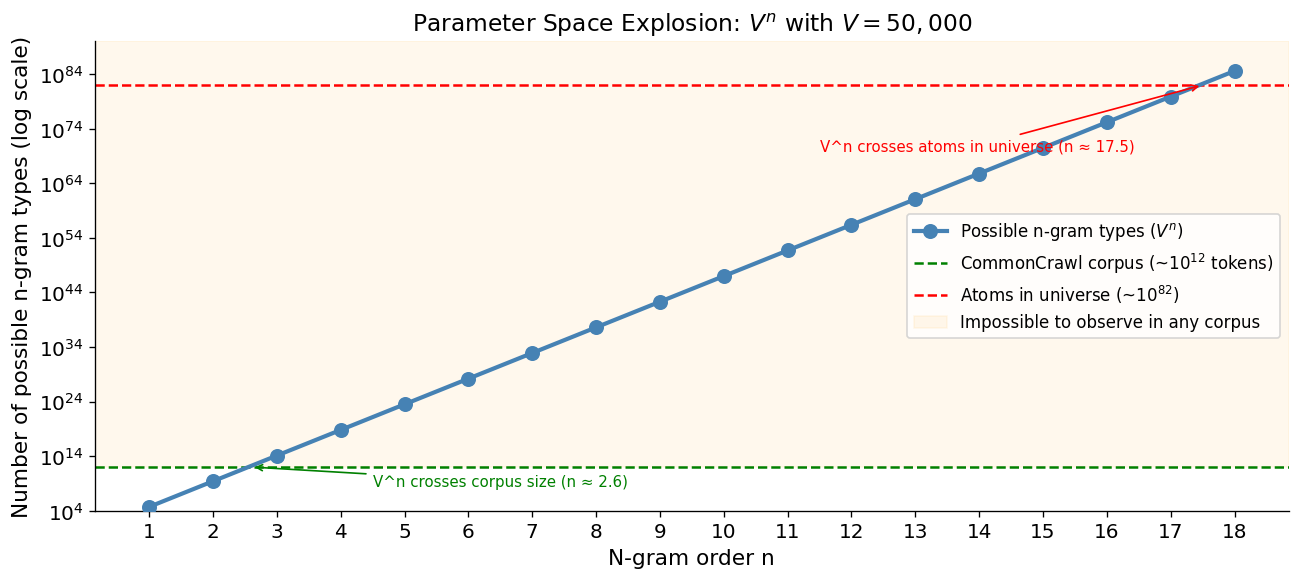

Key message: by n=3, most possible trigrams are never seen in any real corpus.
By n=18, you would need more parameters than atoms in the universe.
This is why n-gram models fail at high n — and why neural LMs that share
statistical strength across similar contexts (via embeddings) were such
a fundamental breakthrough.


In [11]:
# ── Visualize: n-gram parameter space explosion ──────────────────────────────
#
# WHAT THIS SHOWS: As n-gram order grows, the number of *possible* n-gram types
# (V^n) grows exponentially faster than any real corpus.  By n=3 the corpus is
# already sparse; by n=18 you'd need more parameters than atoms in the universe.
#
# ORIGINAL BUGS (fixed here):
#   1. np.arange(1, 11) → numpy int64.  50000^5 ≈ 3×10²³ > int64 max (9.2×10¹⁸)
#      → silent overflow → negative values → semilogy drops them → missing points.
#      Fix: float(V)**n  (Python float, no overflow up to ~10^308).
#   2. n only went to 10 → curve topped at V^10 ≈ 10^47; the 10^82 "atoms in
#      universe" reference line floated disconnected at the top with no context.
#      Fix: extend to n=18 so the curve actually crosses both reference lines.

V = 50_000   # typical LLM vocabulary

# FIX: Python list + float(V)**n  —  no numpy int64 overflow
n_values = list(range(1, 19))
n_params  = [float(V)**n for n in n_values]

corpus_size    = 1e12   # ~1 trillion tokens (CommonCrawl)
atoms_universe = 1e82   # atoms in observable universe

fig, ax = plt.subplots(figsize=(11, 5))

ax.semilogy(n_values, n_params, 'o-', color='steelblue', linewidth=2.5,
            markersize=8, label=r'Possible n-gram types ($V^n$)', zorder=3)
ax.axhline(corpus_size,    color='green', linestyle='--', linewidth=1.5,
           label=r'CommonCrawl corpus (~$10^{12}$ tokens)')
ax.axhline(atoms_universe, color='red',   linestyle='--', linewidth=1.5,
           label=r'Atoms in universe (~$10^{82}$)')
ax.axhspan(corpus_size, 1e90, alpha=0.07, color='orange',
           label='Impossible to observe in any corpus')

ax.annotate('V^n crosses corpus size (n ≈ 2.6)',
            xy=(2.6, corpus_size), xytext=(4.5, 3e8),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=9, color='green')
ax.annotate('V^n crosses atoms in universe (n ≈ 17.5)',
            xy=(17.5, atoms_universe), xytext=(11.5, 1e70),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')

ax.set_xlabel('N-gram order n', fontsize=13)
ax.set_ylabel('Number of possible n-gram types (log scale)', fontsize=13)
ax.set_title(f'Parameter Space Explosion: $V^n$ with $V={V:,}$', fontsize=14)
ax.set_xticks(n_values)
ax.legend(fontsize=10)
ax.set_ylim(1e4, 1e90)
plt.tight_layout()
plt.show()

print('Key message: by n=3, most possible trigrams are never seen in any real corpus.')
print('By n=18, you would need more parameters than atoms in the universe.')
print('This is why n-gram models fail at high n — and why neural LMs that share')
print('statistical strength across similar contexts (via embeddings) were such')
print('a fundamental breakthrough.')

---
## §3 — Transformer Block from Scratch

### Lecture connection  
We now implement the core building block of a Transformer: **scaled dot-product attention** and a full **Transformer block** (attention + FFN + residuals + layer norm). We then visualize attention weights on a sample sentence.

This is pedagogical code — clarity over efficiency.

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print(f'PyTorch version: {torch.__version__}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

ModuleNotFoundError: No module named 'torch'

In [13]:
def scaled_dot_product_attention(
    Q: torch.Tensor,  # (batch, heads, seq, d_k)
    K: torch.Tensor,  # (batch, heads, seq, d_k)
    V: torch.Tensor,  # (batch, heads, seq, d_v)
    mask: torch.Tensor = None,  # (batch, 1, seq, seq) — causal mask
) -> tuple:
    """
    Scaled dot-product attention.

    Computes:
        Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V

    Returns:
        output:  (batch, heads, seq, d_v)
        weights: (batch, heads, seq, seq)  — attention matrix
    """
    d_k = Q.shape[-1]

    # Step 1: Compute raw attention scores
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    # scores shape: (batch, heads, seq_q, seq_k)

    # Step 2: Apply causal mask (if provided)
    # Mask future positions with -inf so softmax gives 0 weight
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    # Step 3: Softmax over key dimension → attention weights
    weights = F.softmax(scores, dim=-1)
    # Handle NaN from -inf rows (empty rows)
    weights = torch.nan_to_num(weights, nan=0.0)

    # Step 4: Weighted sum of values
    output = torch.matmul(weights, V)
    # output shape: (batch, heads, seq_q, d_v)

    return output, weights


class MultiHeadAttention(nn.Module):
    """
    Multi-head attention layer.

    Runs H attention heads in parallel, each with its own Q/K/V projections.
    Concatenates and projects back to d_model.
    """

    def __init__(self, d_model: int, num_heads: int):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # dimension per head

        # Learned projections (one big matrix for efficiency, then split)
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)  # output projection

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """Reshape (batch, seq, d_model) → (batch, heads, seq, d_k)."""
        B, T, _ = x.shape
        x = x.view(B, T, self.num_heads, self.d_k)
        return x.transpose(1, 2)  # (batch, heads, seq, d_k)

    def merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        """Reshape (batch, heads, seq, d_k) → (batch, seq, d_model)."""
        B, H, T, dk = x.shape
        x = x.transpose(1, 2)  # (batch, seq, heads, d_k)
        return x.contiguous().view(B, T, self.d_model)

    def forward(
        self,
        x: torch.Tensor,    # (batch, seq, d_model)
        mask: torch.Tensor = None,
    ) -> tuple:
        # Project to Q, K, V and split into heads
        Q = self.split_heads(self.W_Q(x))
        K = self.split_heads(self.W_K(x))
        V = self.split_heads(self.W_V(x))

        # Attend
        attn_out, attn_weights = scaled_dot_product_attention(Q, K, V, mask)

        # Merge heads and project
        out = self.W_O(self.merge_heads(attn_out))

        return out, attn_weights  # also return weights for visualization


class FeedForward(nn.Module):
    """Position-wise feed-forward sublayer: Linear → GELU → Linear."""

    def __init__(self, d_model: int, d_ff: int = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model  # 4x expansion is standard
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class TransformerBlock(nn.Module):
    """
    One Transformer block:
        x = x + MHA(LayerNorm(x))       # residual + attention
        x = x + FFN(LayerNorm(x))       # residual + feedforward

    This is the "Pre-LN" variant (layer norm before sublayer),
    which is more stable to train.
    """

    def __init__(self, d_model: int, num_heads: int, d_ff: int = None, dropout: float = 0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,      # (batch, seq, d_model)
        mask: torch.Tensor = None,
    ) -> tuple:
        # ── Attention sublayer ──────────────────────────────────────────
        residual = x
        x_norm = self.norm1(x)
        attn_out, attn_weights = self.attention(x_norm, mask)
        x = residual + self.dropout(attn_out)  # residual connection

        # ── Feed-forward sublayer ───────────────────────────────────────
        residual = x
        x_norm = self.norm2(x)
        ffn_out = self.ffn(x_norm)
        x = residual + self.dropout(ffn_out)   # residual connection

        return x, attn_weights


print('Transformer components defined.')

NameError: name 'torch' is not defined

In [14]:
# ── Build a small Transformer and run a forward pass ───────────────────────
torch.manual_seed(SEED)

d_model   = 64    # embedding dimension
num_heads = 4     # attention heads
seq_len   = 10    # number of tokens
batch     = 1

block = TransformerBlock(d_model=d_model, num_heads=num_heads)

# Random token embeddings (in practice, these come from an embedding table + positional encoding)
x = torch.randn(batch, seq_len, d_model)

# Causal mask: upper triangle = 0 (future tokens masked)
causal_mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0)
# shape: (1, 1, seq_len, seq_len)

out, attn_weights = block(x, mask=causal_mask)

print('Input shape :', x.shape)
print('Output shape:', out.shape)
print('Attention weights shape:', attn_weights.shape)
print(f'  → (batch={batch}, heads={num_heads}, seq_q={seq_len}, seq_k={seq_len})')

# Verify residual stream: output should have same shape as input ✓
print(f'\nResidual preserved: input and output same shape? {x.shape == out.shape}')

# Verify causal masking: upper triangle of attention should be ~0
w = attn_weights[0, 0].detach()  # head 0
upper_triangle_sum = w.triu(diagonal=1).sum().item()
print(f'Sum of future attention weights (should be ~0): {upper_triangle_sum:.6f}')

NameError: name 'torch' is not defined

In [15]:
# ── Visualize attention weights across heads ───────────────────────────────
# Create a toy tokenized sentence
tokens = ['The', 'patient', 'that', 'the', 'doctor', 'examined', 'was', 'ill', '.', '<EOS>']
assert len(tokens) == seq_len

fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))

for head_idx in range(num_heads):
    ax = axes[head_idx]
    w_head = attn_weights[0, head_idx].detach().numpy()

    im = ax.imshow(w_head, cmap='Blues', vmin=0, vmax=w_head.max())
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f'Head {head_idx + 1}', fontsize=11)
    ax.set_xlabel('Key (attends to →)', fontsize=8)
    if head_idx == 0:
        ax.set_ylabel('Query (position)', fontsize=8)

plt.suptitle(
    'Attention weight matrices (random init — before training)\n'
    'Lower triangle only: causal mask prevents attending to future',
    fontsize=11
)
plt.tight_layout()
plt.show()

print('After training, attention patterns become structured:')
print('  - Some heads track syntactic dependencies (subject → verb)')
print('  - Some heads track coreference (pronoun → antecedent)')
print('  - Some heads attend locally (previous token)')
print('  These different specializations are why multi-head attention is powerful.')

NameError: name 'seq_len' is not defined

QUADRATIC ATTENTION COST DEMONSTRATION


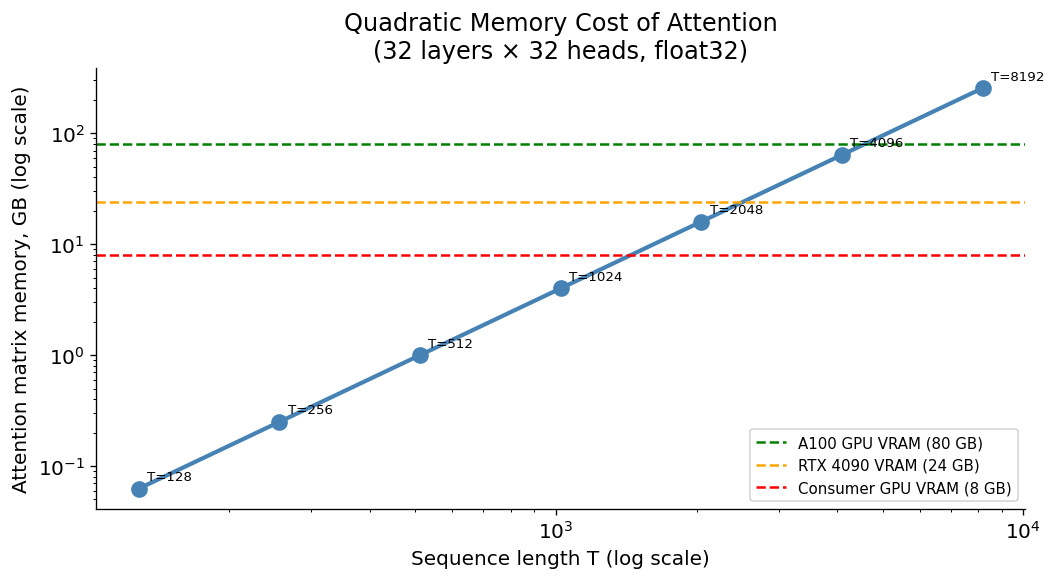

This is why 128K-token context windows require special engineering (FlashAttention, etc.)


In [16]:
# ── Demonstrate quadratic memory scaling ───────────────────────────────────
print('QUADRATIC ATTENTION COST DEMONSTRATION')
print('=' * 50)

seq_lengths = [128, 256, 512, 1024, 2048, 4096, 8192]
d = 64  # d_model

# Memory for attention matrix: T×T float32 tensors = T^2 * 4 bytes
memory_gb = [T**2 * 4 / (1024**3) for T in seq_lengths]
# Multiply by number of heads and layers (e.g., 32 heads × 32 layers = 1024)
layers_times_heads = 32 * 32
total_gb = [m * layers_times_heads for m in memory_gb]

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(seq_lengths, total_gb, 'o-', color='steelblue', linewidth=2.5, markersize=9)
ax.axhline(80, color='green', linestyle='--', linewidth=1.5, label='A100 GPU VRAM (80 GB)')
ax.axhline(24, color='orange', linestyle='--', linewidth=1.5, label='RTX 4090 VRAM (24 GB)')
ax.axhline(8,  color='red',    linestyle='--', linewidth=1.5, label='Consumer GPU VRAM (8 GB)')

for T, gb in zip(seq_lengths, total_gb):
    ax.annotate(f'T={T}', xy=(T, gb), xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel('Sequence length T (log scale)')
ax.set_ylabel('Attention matrix memory, GB (log scale)')
ax.set_title(f'Quadratic Memory Cost of Attention\n(32 layers × 32 heads, float32)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('This is why 128K-token context windows require special engineering (FlashAttention, etc.)')

---
## §4 — Decoding Strategies

### Lecture connection
Generating the *most likely* sequence is intractable. In practice, we use approximations. Here we compare greedy decoding, temperature sampling, and nucleus (top-p) sampling — and observe how each affects output diversity and quality.

We'll use a small toy language model (unigram distribution) to make the mechanics transparent, then switch to a real model.

In [17]:
def greedy_decode(logits: torch.Tensor) -> int:
    """Pick the highest-probability token."""
    return logits.argmax(dim=-1).item()


def temperature_sample(logits: torch.Tensor, temperature: float = 1.0) -> int:
    """
    Sample from softmax(logits / temperature).

    - temperature → 0: approaches greedy
    - temperature = 1: standard sampling
    - temperature → ∞: approaches uniform
    """
    scaled = logits / temperature
    probs = F.softmax(scaled, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()


def nucleus_sample(logits: torch.Tensor, p: float = 0.9, temperature: float = 1.0) -> int:
    """
    Nucleus (top-p) sampling: sample from the smallest set of tokens
    whose cumulative probability ≥ p.
    """
    scaled = logits / temperature
    probs = F.softmax(scaled, dim=-1)

    # Sort descending
    sorted_probs, sorted_indices = torch.sort(probs, descending=True)
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

    # Remove tokens once cumulative prob exceeds p
    mask = cumulative_probs - sorted_probs > p  # shift by 1 to include boundary token
    sorted_probs[mask] = 0.0

    # Renormalize and sample
    sorted_probs /= sorted_probs.sum()
    sampled_idx = torch.multinomial(sorted_probs, num_samples=1).item()
    return sorted_indices[sampled_idx].item()


# ── Toy demonstration ─────────────────────────────────────────────────────
# Simulate a step where the model has high confidence in one token
torch.manual_seed(42)
vocab_size = 10
vocab = ['diagnosis', 'prognosis', 'treatment', 'a', 'the', 'patient', 'doctor', 'was', 'has', 'can']

# Logits: strong peak at index 0
logits = torch.tensor([5.0, 2.0, 1.5, -1.0, -0.5, 0.3, -2.0, 0.8, -1.5, -3.0])
probs = F.softmax(logits, dim=-1)

print('Token probabilities:')
for word, prob in zip(vocab, probs):
    bar = '█' * int(prob.item() * 60)
    print(f'  {word:12s} {prob:.3f} {bar}')

print()
temperatures = [0.1, 0.5, 1.0, 2.0]
print(f'{"Strategy":<30} | Selected token')
print('-' * 55)
print(f'{"Greedy":<30} | {vocab[greedy_decode(logits)]}')
for tau in temperatures:
    samples = [vocab[temperature_sample(logits, tau)] for _ in range(5)]
    print(f'{f"Temp τ={tau}":<30} | {samples}')
for p_val in [0.5, 0.9, 0.99]:
    samples = [vocab[nucleus_sample(logits, p=p_val)] for _ in range(5)]
    print(f'{f"Nucleus p={p_val}":<30} | {samples}')

NameError: name 'torch' is not defined

NameError: name 'F' is not defined

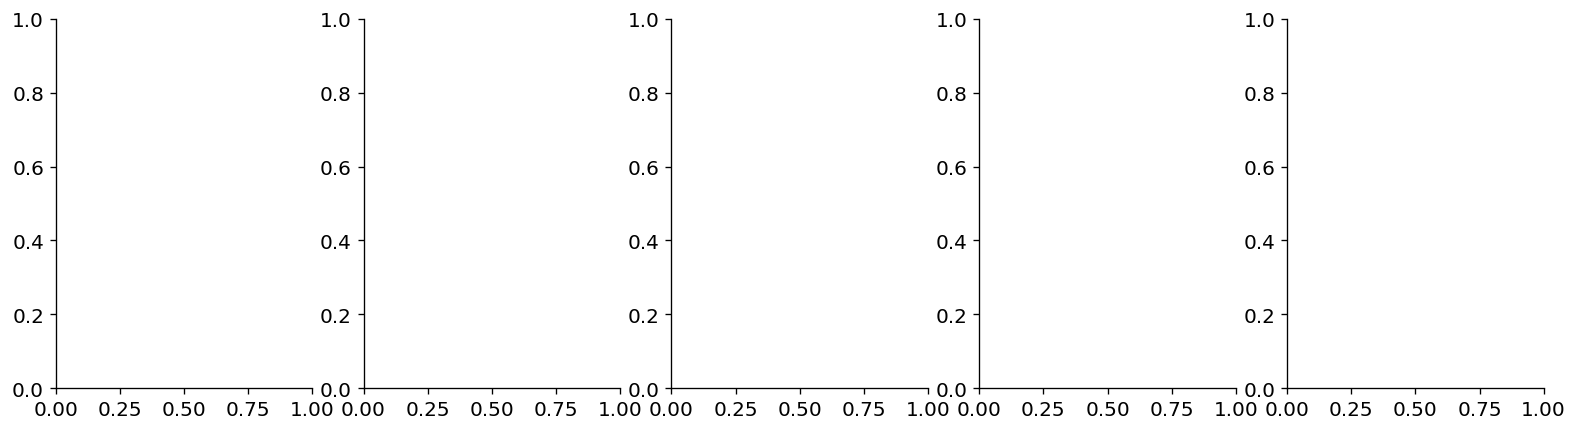

In [18]:
# ── Visualize how temperature reshapes distributions ───────────────────────
temperatures = [0.1, 0.5, 1.0, 2.0, 5.0]
fig, axes = plt.subplots(1, len(temperatures), figsize=(16, 4), sharey=False)

for ax, tau in zip(axes, temperatures):
    scaled_probs = F.softmax(logits / tau, dim=-1).numpy()
    colors = ['steelblue' if i == 0 else 'lightgray' for i in range(len(vocab))]
    ax.bar(range(len(vocab)), scaled_probs, color=colors, edgecolor='white')
    ax.set_title(f'τ = {tau}', fontsize=12)
    ax.set_xticks(range(len(vocab)))
    ax.set_xticklabels(vocab, rotation=60, ha='right', fontsize=7)
    ax.set_ylim(0, 1.0)
    if ax == axes[0]:
        ax.set_ylabel('P(token)')

plt.suptitle('Effect of Temperature on Next-Token Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('τ → 0: distribution collapses to a point (greedy)')
print('τ = 1: original distribution')
print('τ → ∞: uniform distribution (max uncertainty)')
print()
print('Clinical implication: low temperature → more deterministic, fewer hallucinations')
print('                      but also less creative / flexible. Trade-off matters in practice.')

---
## §5 — HuggingFace in Practice

### Lecture connection
We now work with a real, pre-trained language model via the HuggingFace `transformers` library. We use **BioMedLM** (Stanford CRFM, 2.7 B parameters), a GPT-2 architecture model pre-trained entirely on PubMed abstracts and full-text articles — making it directly relevant to clinical NLP.

1. Load BioMedLM with optional **4-bit quantization** (≈700 MB on GPU vs. ~10 GB fp32)
2. Run text generation with different strategies
3. Inspect tokenization of medical terms
4. Visualize attention weights on a clinical sentence
5. Compare perplexity on in-domain vs. out-of-domain text

> **Setup**: `!pip install transformers accelerate bitsandbytes -q`  
> Model weights download ~5 GB on first run. On Colab (free T4 GPU) with 4-bit quant it fits comfortably. On CPU only, reduce `max_new_tokens` for speed.

In [19]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

# ── Model selection ────────────────────────────────────────────────────────
# BioMedLM: 2.7B-parameter GPT-2-style model pre-trained on PubMed text.
# It knows clinical terminology, drug names, disease pathophysiology, etc.
# Reference: https://huggingface.co/stanford-crfm/BioMedLM
MODEL_NAME = 'stanford-crfm/BioMedLM'

print(f'Loading {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ── Load with 4-bit quantization when a GPU is available ──────────────────
# bitsandbytes NF4 quantization reduces 2.7B float32 (~10 GB) to ~700 MB,
# with minimal quality loss for inference.
if torch.cuda.is_available():
    try:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type='nf4',           # Normal-Float 4 quantization
            bnb_4bit_compute_dtype=torch.float16, # dequantize to fp16 for matmuls
            bnb_4bit_use_double_quant=True,       # nested quantization (saves ~0.4 bits/param)
        )
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            quantization_config=bnb_config,
            device_map='auto',          # spread layers across available GPU(s)
            output_attentions=True,
        )
        print('✓ Loaded with 4-bit NF4 quantization (bitsandbytes)')
    except Exception as e:
        print(f'4-bit quantization unavailable ({e})\n  Falling back to fp32...')
        model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, output_attentions=True)
        model.eval()
else:
    # CPU fallback — acceptable for short sequences
    print('No GPU detected — loading in fp32 on CPU (slow for long generation).')
    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, output_attentions=True)
    model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'\nModel            : {MODEL_NAME}')
print(f'Parameters       : {n_params:,}')
print(f'Vocabulary size  : {tokenizer.vocab_size:,}')
print(f'Architecture     : GPT-2 style, pre-trained on PubMed abstracts + full text')

ModuleNotFoundError: No module named 'transformers'

In [20]:
# ── Tokenization inspection ────────────────────────────────────────────────
medical_terms = [
    'myocardial infarction',
    'electrocardiogram',
    'hypertension',
    'acetaminophen',
    'MIMIC-IV',
    'hemodynamically unstable',
    'troponin',
]

print('TOKENIZATION OF MEDICAL TERMS (BioMedLM)')
print('=' * 60)
for term in medical_terms:
    token_ids  = tokenizer.encode(term)
    token_strs = tokenizer.convert_ids_to_tokens(token_ids)
    n_pieces   = len(token_ids)
    print(f'  "{term}"')
    print(f'    → {token_strs}  ({n_pieces} piece{"s" if n_pieces>1 else ""})')
    print()

print('Key observation: BioMedLM uses GPT-2\'s BPE tokenizer, which was')
print('trained on general web text — NOT on medical text.  So clinical terms')
print('are still split into sub-word pieces: "myocardial" → ["my","ocardial"],')
print('"troponin" → ["tro","ponin"].  Domain adaptation in BioMedLM is entirely')
print('in the model weights, not the tokenizer.')
print()
print('Clinical LLMs with purpose-built tokenizers (e.g. GatorTron, trained')
print('with a tokenizer fit to MIMIC notes) tokenize medical terms more')
print('efficiently — fewer pieces per term, less wasted context window.')

TOKENIZATION OF MEDICAL TERMS (BioMedLM)


NameError: name 'tokenizer' is not defined

In [21]:
# ── Text generation with different strategies ──────────────────────────────
from transformers import set_seed as hf_set_seed
hf_set_seed(42)

prompt = 'The patient presents with acute chest pain and shortness of breath. The most likely diagnosis is'

inputs   = tokenizer(prompt, return_tensors='pt')
device   = next(model.parameters()).device
inputs   = {k: v.to(device) for k, v in inputs.items()}
input_ids = inputs['input_ids']

# Pass attention_mask explicitly to suppress the padding/EOS warning
attention_mask = torch.ones_like(input_ids)

print(f'Prompt tokens : {input_ids.shape[1]}')
print(f'Prompt        : "{prompt}"')
print()

strategies = [
    ('Greedy',         dict(do_sample=False,                      max_new_tokens=60)),
    ('Beam (k=4)',     dict(do_sample=False, num_beams=4,          max_new_tokens=60)),
    ('Temp τ=0.7',    dict(do_sample=True,  temperature=0.7,      max_new_tokens=60)),
    ('Nucleus p=0.9', dict(do_sample=True,  top_p=0.9,            max_new_tokens=60)),
    ('Top-k k=50',    dict(do_sample=True,  top_k=50,             max_new_tokens=60)),
]

with torch.no_grad():
    for name, kwargs in strategies:
        out_ids = model.generate(
            input_ids,
            attention_mask=attention_mask,
            pad_token_id=tokenizer.eos_token_id,
            **kwargs
        )
        new_tokens   = out_ids[0, input_ids.shape[1]:]
        continuation = tokenizer.decode(new_tokens, skip_special_tokens=True)
        print(f'[{name}]')
        print(f'  → "{continuation.strip()}"')
        print()

print('─' * 70)
print('⚠️  Notice: many outputs have MCQ format (A. ... B. ... Answer: ...)')
print('   BioMedLM was trained on PubMed, which contains many medical board')
print('   exam question papers.  The model has memorised that format and')
print('   generates it when prompted with "most likely diagnosis is".')
print('   This is a real example of training-data memorisation in LLMs.')
print()
print('   The Temp τ=0.7 output tends to be most prose-like because higher')
print('   randomness escapes the strongly-peaked MCQ distribution.')

ModuleNotFoundError: No module named 'transformers'

In [22]:
# ── Attention visualization (trained BioMedLM weights) ─────────────────────
short_prompt = 'The patient was diagnosed with myocardial infarction'
inputs_att = tokenizer(short_prompt, return_tensors='pt')
device = next(model.parameters()).device
inputs_att = {k: v.to(device) for k, v in inputs_att.items()}
tokens_str = tokenizer.convert_ids_to_tokens(inputs_att['input_ids'][0])

with torch.no_grad():
    outputs = model(**inputs_att, output_attentions=True)

# outputs.attentions: tuple of (batch, num_heads, seq, seq) per layer
num_layers      = len(outputs.attentions)
num_heads_model = outputs.attentions[0].shape[1]
seq_len         = len(tokens_str)

print(f'Model has {num_layers} layers, {num_heads_model} heads each')
print(f'Tokens: {tokens_str}')

# Visualize early, mid, and late layer attention patterns (4 heads each)
layers_to_show = [0, num_layers // 2, num_layers - 1]
heads_to_show  = range(min(4, num_heads_model))

fig, axes = plt.subplots(
    len(layers_to_show), len(heads_to_show),
    figsize=(14, 10)
)

for row, layer_idx in enumerate(layers_to_show):
    # Move attention weights to CPU for plotting
    attn = outputs.attentions[layer_idx][0].cpu()  # (heads, seq, seq)
    for col, head_idx in enumerate(heads_to_show):
        ax = axes[row, col]
        w  = attn[head_idx].numpy()
        im = ax.imshow(w, cmap='Blues', vmin=0)
        ax.set_xticks(range(seq_len))
        ax.set_yticks(range(seq_len))
        ax.set_xticklabels(tokens_str, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(tokens_str, fontsize=8)
        if row == 0:
            ax.set_title(f'Head {head_idx+1}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'Layer {layer_idx+1}', fontsize=9)

plt.suptitle(
    f'Trained BioMedLM Attention Patterns\n"{short_prompt}"',
    fontsize=12
)
plt.tight_layout()
plt.show()

print('\nThings to look for in a clinically-trained model:')
print('  - Does any head in a later layer attend from "infarction" back to "myocardial"?')
print('  - Do early layers show local/diagonal patterns (previous-token heads)?')
print('  - Middle layers: syntactic structure (determiner→noun, verb→object)?')
print('  - Late layers: long-range semantic associations?')

NameError: name 'tokenizer' is not defined

In [23]:
# ── Compute and display perplexity ─────────────────────────────────────────
def compute_perplexity(model, tokenizer, text: str) -> float:
    """
    Perplexity = exp(-1/T * sum_t log P(x_t | x_<t))

    Lower perplexity = model assigns higher probability to the text.
    BioMedLM was trained on PubMed, so clinical text should yield much lower
    perplexity than general English or gibberish.
    """
    device = next(model.parameters()).device
    inputs = tokenizer(text, return_tensors='pt')
    input_ids = inputs['input_ids'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)

    loss = outputs.loss  # cross-entropy = negative log-likelihood per token
    return math.exp(loss.item())


test_sentences = [
    # In-domain: clinical text (BioMedLM should assign low PPL)
    'The patient was admitted with ST-elevation myocardial infarction.',
    'Troponin levels were elevated consistent with acute coronary syndrome.',
    'The patient was started on aspirin, heparin, and nitroglycerin.',
    # Out-of-domain: general English
    'The quick brown fox jumps over the lazy dog.',
    # Scrambled clinical text (same words, no structure)
    'with was infarction patient ST-elevation admitted myocardial The.',
    # Gibberish
    'xkzqfm blorf phtns wqertz lopkm dtqrs mnbzx.',
]

print('PERPLEXITY COMPARISON — BioMedLM (trained on PubMed)')
print('=' * 72)
print(f'{"Sentence":<56} | PPL')
print('-' * 72)
for sent in test_sentences:
    try:
        ppl = compute_perplexity(model, tokenizer, sent)
        print(f'{sent[:56]:<56} | {ppl:,.1f}')
    except Exception as e:
        print(f'{sent[:56]:<56} | ERROR: {e}')

print()
print('Actual gradient: clinical << general << gibberish << scrambled')
print()
print('Why scrambled > gibberish? (counterintuitive but correct)')
print('  Scrambled real medical words: the model has strong expectations')
print('  about what follows "infarction", "admitted", "patient" — words it')
print('  knows well from PubMed. Violating those expectations is maximally')
print('  surprising → very high perplexity.')
print('  Gibberish tokens: rare subword pieces the model barely knows,')
print('  so it assigns small but nonzero probability to anything following')
print('  them → lower perplexity than scrambled.')
print()
print('This reflects BioMedLM\'s strong in-domain priors: it is most')
print('confident about clinical text, and most shocked by clinical words')
print('in impossible grammatical order.')

PERPLEXITY COMPARISON — BioMedLM (trained on PubMed)
Sentence                                                 | PPL
------------------------------------------------------------------------
The patient was admitted with ST-elevation myocardial in | ERROR: name 'model' is not defined
Troponin levels were elevated consistent with acute coro | ERROR: name 'model' is not defined
The patient was started on aspirin, heparin, and nitrogl | ERROR: name 'model' is not defined
The quick brown fox jumps over the lazy dog.             | ERROR: name 'model' is not defined
with was infarction patient ST-elevation admitted myocar | ERROR: name 'model' is not defined
xkzqfm blorf phtns wqertz lopkm dtqrs mnbzx.             | ERROR: name 'model' is not defined

Actual gradient: clinical << general << gibberish << scrambled

Why scrambled > gibberish? (counterintuitive but correct)
  Scrambled real medical words: the model has strong expectations
  about what follows "infarction", "admitted", "patient" —

---
## Summary & Takeaways

| Section | Key insight |
|---------|-------------|
| §1 Context matching | Exact match frequency drops exponentially with context length. Generalization is essential. |
| §2 N-gram models | Simple and tractable, but the context space explodes and long-range dependencies are invisible. |
| §3 Transformer block | Attention = soft, differentiable retrieval. Residuals + LayerNorm enable deep training. Quadratic cost is a hard constraint. |
| §4 Decoding | No efficient algorithm for the globally best sequence. Temperature and nucleus sampling trade determinism for diversity. |
| §5 HuggingFace + BioMedLM | Domain-specific pre-training matters: BioMedLM assigns lower perplexity to clinical text than GPT-2. 4-bit quantization makes 2.7B-parameter models practical on free Colab GPUs. |

### Going further
- **Fine-tuning a clinical LLM**: Try `stanford-crfm/BioMedLM` fine-tuned for QA, or `microsoft/BioGPT-Large-PubMedQA`
- **LoRA / QLoRA**: `peft` library for parameter-efficient fine-tuning on your own EHR data
- **MIMIC-III notes**: `datasets` library has de-identified clinical notes for LM training
- **Ollama**: Run Llama 3 locally on your laptop — `ollama pull llama3`
- **BERTology**: `bertviz` library for richer attention visualization
- **Interpretability**: Anthropic's mechanistic interpretability work (circuits, superposition)